# Sistem Rekomendasi Makanan

## 1. Menginstall library yg dibutuhkan

In [1]:
!pip install opendatasets

## 2. Mengunduh dataset

In [2]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/schemersays/food-recommendation-system')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bintangultraman
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/schemersays/food-recommendation-system


100%|██████████| 24.8k/24.8k [00:00<00:00, 4.18MB/s]

## 3. Menyiapkan library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk content-based filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Library untuk collaborative filtering
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

# **4. Data Understanding**

### 4.1 Membaca dataset makanan dan rating

In [4]:
df_makanan = pd.read_csv('/content/food-recommendation-system/1662574418893344.csv')
df_rating = pd.read_csv('/content/food-recommendation-system/ratings.csv')

print(df_makanan.head(3))
print("<=================>")
print(df_makanan.shape)
print("<=================>")
df_makanan.info()

   Food_ID                  Name        C_Type  Veg_Non  \
0        1   summer squash salad  Healthy Food      veg   
1        2  chicken minced salad  Healthy Food  non-veg   
2        3  sweet chilli almonds         Snack      veg   

                                            Describe  
0  white balsamic vinegar, lemon juice, lemon rin...  
1  olive oil, chicken mince, garlic (minced), oni...  
2  almonds whole, egg white, curry leaves, salt, ...  
<=================>
(400, 5)
<=================>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Food_ID   400 non-null    int64 
 1   Name      400 non-null    object
 2   C_Type    400 non-null    object
 3   Veg_Non   400 non-null    object
 4   Describe  400 non-null    object
dtypes: int64(1), object(4)
memory usage: 15.8+ KB


Dari sel kode di atas, dapat dilihat bahwa dataset makanan memiliki 400 baris dengan 5 kolom.

### 4.2 Cek kategori makanan unik

In [5]:
print(len(df_makanan['C_Type'].unique()))
print(df_makanan['C_Type'].unique())

16
['Healthy Food' 'Snack' 'Dessert' 'Japanese' 'Indian' 'French' 'Mexican'
 'Italian' 'Chinese' 'Beverage' 'Thai' 'Korean' ' Korean' 'Vietnames'
 'Nepalese' 'Spanish']


Dari sel kode di atas, dapat dilihat bahwa ada 16 jenis makanan yang berbeda di dalam dataset. Namun, terlihat bahwa makanan Korea memiliki dua nilai unik yang harus dikoreksi terlebih dahulu. Jadi, sel kode di bawah ini digunakan untuk mengoreksi yang satu ini.

### 4.3 Membersihkan nama kategori

In [6]:
df_makanan['C_Type'] = df_makanan['C_Type'].replace([' Korean'], 'Korean')
print(len(df_makanan['C_Type'].unique()))
print(df_makanan['C_Type'].unique())

15
['Healthy Food' 'Snack' 'Dessert' 'Japanese' 'Indian' 'French' 'Mexican'
 'Italian' 'Chinese' 'Beverage' 'Thai' 'Korean' 'Vietnames' 'Nepalese'
 'Spanish']


### 4.4 Distribusi kategori

<Axes: ylabel='C_Type'>

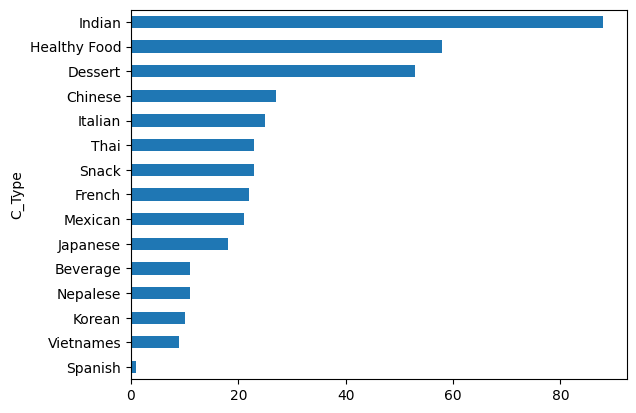

In [7]:
df_makanan['C_Type'].value_counts().sort_values().plot(kind='barh')

Sel kode di atas adalah plot distribusi data jenis makanan. Dari plot tersebut, dapat dilihat bahwa jenis makanan yang paling dominan adalah makanan India, diikuti oleh makanan sehat dan makanan penutup.

In [8]:
print(df_rating.head(3))
print("<=================>")
print(df_rating.shape)
print("<=================>")
df_rating.info()


   User_ID  Food_ID  Rating
0      1.0     88.0     4.0
1      1.0     46.0     3.0
2      1.0     24.0     5.0
<=================>
(512, 3)
<=================>
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   User_ID  511 non-null    float64
 1   Food_ID  511 non-null    float64
 2   Rating   511 non-null    float64
dtypes: float64(3)
memory usage: 12.1 KB


In [9]:
print('Jumlah User_ID:', len(df_rating['User_ID'].unique()))
print("<=================>")
print('Jumlah Food_ID:', len(df_rating['Food_ID'].unique()))
print("<=================>")
print(df_rating.describe())

Jumlah User_ID: 101
<=================>
Jumlah Food_ID: 310
<=================>
          User_ID     Food_ID      Rating
count  511.000000  511.000000  511.000000
mean    49.068493  125.311155    5.438356
std     28.739213   91.292629    2.866236
min      1.000000    1.000000    1.000000
25%     25.000000   45.500000    3.000000
50%     49.000000  111.000000    5.000000
75%     72.000000  204.000000    8.000000
max    100.000000  309.000000   10.000000


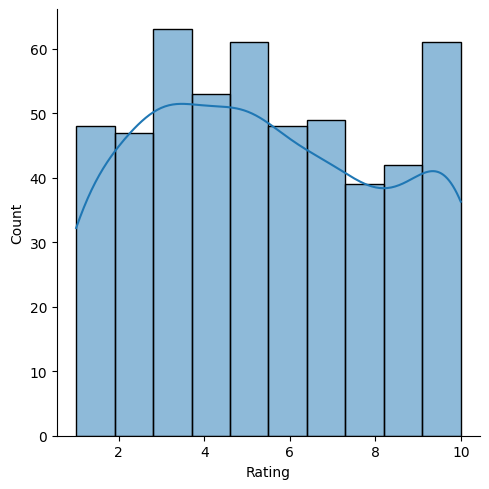

In [10]:
sns.displot(df_rating['Rating'], kde=True, bins=10)

Sel kode di atas adalah tentang plot distribusi data tentang rating. Dari plot ini, dapat dilihat bahwa distribusi rating cenderung berada di sekitar angka 3, 5, dan 10.

# **5. Data Preprocessing**

### 5.1 Menggabungkan Data

In [11]:
df_gabungan = pd.merge(df_rating, df_makanan[['Food_ID', 'Name', 'C_Type']], on='Food_ID', how='left')
print(df_gabungan.head())
print(df_gabungan.isnull().sum())
df_gabungan = df_gabungan.dropna()

   User_ID  Food_ID  Rating                        Name    C_Type
0      1.0     88.0     4.0     peri peri chicken satay     Snack
1      1.0     46.0     3.0     steam bunny chicken bao  Japanese
2      1.0     24.0     5.0  green lentil dessert fudge   Dessert
3      1.0     25.0     4.0          cashew nut cookies   Dessert
4      2.0     49.0     1.0        christmas tree pizza   Italian
User_ID    1
Food_ID    1
Rating     1
Name       1
C_Type     1
dtype: int64


In [12]:
df_rating = df_rating.dropna()

### 5.2 Urutkan berdasarkan Food_ID

In [13]:
df_urut = df_gabungan.sort_values('Food_ID', ascending=True)
print(df_urut.head())
print(len(df_urut['Food_ID'].unique()))
print(df_urut['C_Type'].unique())

     User_ID  Food_ID  Rating                  Name        C_Type
376     71.0      1.0    10.0   summer squash salad  Healthy Food
253     49.0      1.0     5.0   summer squash salad  Healthy Food
116     22.0      2.0     5.0  chicken minced salad  Healthy Food
200     39.0      2.0    10.0  chicken minced salad  Healthy Food
50       9.0      2.0     3.0  chicken minced salad  Healthy Food
309
['Healthy Food' 'Snack' 'Dessert' 'Japanese' 'Indian' 'French' 'Mexican'
 'Italian' 'Chinese' 'Beverage' 'Thai']


### 5.3 Persiapan data makanan tanpa duplikasi

In [14]:
df_prep = df_urut.sort_values('Food_ID').drop_duplicates('Food_ID')
df_prep.loc[df_prep['C_Type'] == 'Healthy Food', 'C_Type'] = 'Healthy_Food'


### 5.4 Ekstraksi kolom untuk content-based filtering

In [15]:
list_id = df_prep['Food_ID'].tolist()
list_nama = df_prep['Name'].tolist()
list_kategori = df_prep['C_Type'].tolist()

print(len(list_id), len(list_nama), len(list_kategori))

309 309 309


Sel kode di atas digunakan untuk mengubah seri `Food_ID`, `Nama`, dan `C_Type` menjadi list.

### 5.5 Membuat dataframe baru

In [16]:
df_makanan_baru = pd.DataFrame({
    'id': list_id,
    'food_name': list_nama,
    'category': list_kategori
})

print(df_makanan_baru.head())
print(df_makanan_baru.sample(5))

    id             food_name      category
0  1.0   summer squash salad  Healthy_Food
1  2.0  chicken minced salad  Healthy_Food
2  3.0  sweet chilli almonds         Snack
3  4.0       tricolour salad  Healthy_Food
4  5.0        christmas cake       Dessert
        id                               food_name category
282  283.0                       veg hakka noodles  Chinese
60    61.0  crunchy vegetable dal sattu croquettes  Italian
90    91.0                         chicken biryani   Indian
46    47.0                       meat lovers pizza  Italian
207  208.0    fennel scented sweet banana fritters  Dessert


# **6. Modeling**

### 6.1 Content-Based Filtering

##### 6.1.1 Membuat TF-IDF vectorizer berdasarkan kategori makanan

In [17]:
tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(df_makanan_baru['category'])
print(tfidf_vect.get_feature_names_out())

['beverage' 'chinese' 'dessert' 'french' 'healthy_food' 'indian' 'italian'
 'japanese' 'mexican' 'snack' 'thai']


In [18]:
tfidf_matrix = tfidf_vect.fit_transform(df_makanan_baru['category'])
print(tfidf_matrix.shape)
print(tfidf_matrix.todense())

(309, 11)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


Sel kode di atas digunakan untuk mengubah vektor tf-idf menjadi matriks menggunakan fungsi todense().

##### 6.1.2 Menampilkan beberapa contoh fitur

In [19]:
df_tfidf = pd.DataFrame(tfidf_matrix.todense(),
                        columns=tfidf_vect.get_feature_names_out(),
                        index=df_makanan_baru['food_name'])
print(df_tfidf.sample(11, axis=1).sample(10, axis=0))

                                   healthy_food  japanese  snack  thai  \
food_name                                                                
crispy herb chicken                         0.0       0.0    0.0   0.0   
sticky rum chicken wings                    0.0       0.0    1.0   0.0   
chicken dragon                              0.0       0.0    0.0   0.0   
spanish artichoke and spinach dip           0.0       0.0    0.0   0.0   
summer squash salad                         1.0       0.0    0.0   0.0   
holi special ice tea thandai                0.0       0.0    0.0   0.0   
chicken gilafi kebab                        0.0       0.0    0.0   0.0   
methi chicken masala                        0.0       0.0    0.0   0.0   
andhra pan fried pomfret                    0.0       0.0    0.0   0.0   
whole wheat cake                            1.0       0.0    0.0   0.0   

                                   indian  beverage  french  mexican  dessert  \
food_name                     

##### 6.1.3 Matriks cosine similarity


In [20]:
cos_sim = cosine_similarity(tfidf_matrix)
df_cosine = pd.DataFrame(cos_sim, index=df_makanan_baru['food_name'], columns=df_makanan_baru['food_name'])
print('Shape:', df_cosine.shape)
print(df_cosine.sample(5, axis=1).sample(10, axis=0))

Shape: (309, 309)
food_name                                       japanese fish stew  \
food_name                                                            
roasted spring chicken with root veggies                       0.0   
chicken dragon                                                 0.0   
baked shankarpali                                              0.0   
couscous with ratatouille - tangy tomato sauce                 0.0   
lamb rogan josh                                                0.0   
vegetable bruschetta                                           0.0   
moong dal kiwi coconut soup                                    0.0   
apple kheer                                                    0.0   
chocolate doughnut                                             0.0   
microwave tandoori chicken                                     0.0   

food_name                                       matcha tea macarons  \
food_name                                                             

In [22]:
def rekomendasi_makanan(nama_makanan, sim_data=df_cosine, items=df_makanan_baru[['food_name', 'category']], top=5):
    # Mengambil indeks kemiripan
    idx_array = sim_data.loc[:, nama_makanan].to_numpy().argpartition(range(-1, -top, -1))
    rekomendasi = sim_data.columns[idx_array[-1:-(top+2):-1]]
    rekomendasi = rekomendasi.drop(nama_makanan, errors='ignore')
    return pd.DataFrame(rekomendasi).merge(items).head(top)

Kode program di atas digunakan untuk membuat sebuah fungsi yang dapat digunakan untuk memberikan rekomendasi makanan dengan input berupa nama makanan. Fungsi ini pertama-tama akan mengambil data dengan menggunakan argpartition untuk mempartisi secara tidak langsung di sepanjang sumbu yang diberikan, mengambil data dengan kemiripan terbesar dari indeks yang ada, dan membuang `food_name` agar nama makanan yang dicari tidak muncul dalam hasil rekomendasi.

In [23]:
print(df_makanan_baru[df_makanan_baru['food_name'] == 'banana chips'])
print(rekomendasi_makanan('banana chips'))

        id     food_name category
305  306.0  banana chips    Snack
                                        food_name category
0                                     puffed rice    Snack
1                  californian breakfast benedict    Snack
2  banana phirni tartlets with fresh strawberries    Snack
3                         baked raw banana samosa    Snack
4                        baked multigrain murukku    Snack


The output of the code cell above shows the food recommendation results. It can be seen that the function outputs 5 food names that have the same category as the food name that has been inputted before, that is Snack category.

### 6.2 Collaborative Filtering

##### 6.2.1 Encoding User_ID dan Food_ID

In [24]:
user_list = df_rating['User_ID'].unique().tolist()
print('User_ID list:', user_list)

User_ID list: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0]


In [25]:
user2idx = {user: idx for idx, user in enumerate(user_list)}
idx2user = {idx: user for idx, user in enumerate(user_list)}
print('Mapping User_ID:', user2idx)
print('Mapping indeks ke User_ID:', idx2user)

Mapping User_ID: {1.0: 0, 2.0: 1, 3.0: 2, 4.0: 3, 5.0: 4, 6.0: 5, 7.0: 6, 8.0: 7, 9.0: 8, 10.0: 9, 11.0: 10, 12.0: 11, 13.0: 12, 14.0: 13, 15.0: 14, 16.0: 15, 17.0: 16, 18.0: 17, 19.0: 18, 20.0: 19, 21.0: 20, 22.0: 21, 23.0: 22, 24.0: 23, 25.0: 24, 26.0: 25, 27.0: 26, 28.0: 27, 29.0: 28, 30.0: 29, 31.0: 30, 32.0: 31, 33.0: 32, 34.0: 33, 35.0: 34, 36.0: 35, 37.0: 36, 38.0: 37, 39.0: 38, 40.0: 39, 41.0: 40, 42.0: 41, 43.0: 42, 44.0: 43, 45.0: 44, 46.0: 45, 47.0: 46, 48.0: 47, 49.0: 48, 50.0: 49, 51.0: 50, 52.0: 51, 53.0: 52, 54.0: 53, 55.0: 54, 56.0: 55, 57.0: 56, 58.0: 57, 59.0: 58, 60.0: 59, 61.0: 60, 62.0: 61, 63.0: 62, 64.0: 63, 65.0: 64, 66.0: 65, 67.0: 66, 68.0: 67, 69.0: 68, 70.0: 69, 71.0: 70, 72.0: 71, 73.0: 72, 74.0: 73, 75.0: 74, 76.0: 75, 77.0: 76, 78.0: 77, 79.0: 78, 80.0: 79, 81.0: 80, 82.0: 81, 83.0: 82, 84.0: 83, 85.0: 84, 86.0: 85, 87.0: 86, 88.0: 87, 89.0: 88, 90.0: 89, 91.0: 90, 92.0: 91, 93.0: 92, 94.0: 93, 95.0: 94, 96.0: 95, 97.0: 96, 98.0: 97, 99.0: 98, 100.0: 99}


In [26]:
food_list = df_rating['Food_ID'].unique().tolist()
food2idx = {food: idx for idx, food in enumerate(food_list)}
idx2food = {idx: food for idx, food in enumerate(food_list)}

##### 6.2.2 Menambahkan kolom encoding pada dataframe rating

In [27]:
df_rating['user'] = df_rating['User_ID'].map(user2idx)
df_rating['food'] = df_rating['Food_ID'].map(food2idx)

n_users = len(user2idx)
n_foods = len(idx2food)
print(n_users, n_foods)

100 309


In [28]:
df_rating['rating'] = df_rating['Rating'].astype(np.float32)
min_rat = df_rating['rating'].min()
max_rat = df_rating['rating'].max()
print('Jumlah User: {}, Jumlah Food: {}, Rating Min: {}, Rating Max: {}'.format(n_users, n_foods, min_rat, max_rat))

Jumlah User: 100, Jumlah Food: 309, Rating Min: 1.0, Rating Max: 10.0


Sel kode di atas digunakan untuk memeriksa jumlah pengguna, jumlah makanan, dan nilai minimum serta maksimum rating yang tersedia pada dataset.

In [29]:
df_rating = df_rating.sample(frac=1, random_state=42)

##### 6.2.3 Menyiapkan data untuk training

In [30]:
X_data = df_rating[['user', 'food']].values
y_data = df_rating['rating'].apply(lambda x: (x - min_rat) / (max_rat - min_rat)).values

split_index = int(0.8 * df_rating.shape[0])
X_train, X_val = X_data[:split_index], X_data[split_index:]
y_train, y_val = y_data[:split_index], y_data[split_index:]
print(X_data, y_data)

[[ 85 286]
 [ 52 206]
 [ 79 276]
 ...
 [ 45 149]
 [ 38 162]
 [ 61  84]] [0.33333333 1.         0.77777778 0.         0.88888889 0.22222222
 0.44444444 1.         0.77777778 0.11111111 0.44444444 0.33333333
 0.55555556 0.77777778 0.77777778 0.33333333 0.88888889 0.11111111
 0.66666667 0.88888889 0.11111111 0.22222222 0.77777778 0.44444444
 0.44444444 0.44444444 0.77777778 1.         0.88888889 0.88888889
 0.33333333 0.33333333 0.88888889 0.11111111 1.         0.44444444
 1.         0.22222222 0.44444444 0.44444444 0.77777778 0.22222222
 0.88888889 1.         0.22222222 0.66666667 1.         0.22222222
 0.         0.55555556 0.22222222 0.77777778 0.66666667 0.44444444
 0.55555556 0.         0.77777778 0.77777778 0.44444444 0.66666667
 1.         0.55555556 0.33333333 0.11111111 1.         0.55555556
 0.44444444 1.         0.22222222 0.66666667 0.66666667 0.
 0.55555556 0.44444444 0.66666667 1.         0.66666667 0.55555556
 1.         1.         0.22222222 1.         0.22222222 0.4444444

Sel kode di atas digunakan untuk membuat variabel `x` dan `y`, diikuti dengan pemisahan data.

##### 6.2.4 Membangun model rekomendasi dengan TensorFlow

In [31]:
class RecommenderModel(tf.keras.Model):
    def __init__(self, total_users, total_foods, embed_size, **kwargs):
        super(RecommenderModel, self).__init__(**kwargs)
        self.user_embed = layers.Embedding(total_users, embed_size,
                                           embeddings_initializer='he_normal',
                                           embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.user_bias = layers.Embedding(total_users, 1)
        self.food_embed = layers.Embedding(total_foods, embed_size,
                                           embeddings_initializer='he_normal',
                                           embeddings_regularizer=keras.regularizers.l2(1e-6))
        self.food_bias = layers.Embedding(total_foods, 1)

    def call(self, inputs):
        u_vec = self.user_embed(inputs[:, 0])
        u_bias = self.user_bias(inputs[:, 0])
        f_vec = self.food_embed(inputs[:, 1])
        f_bias = self.food_bias(inputs[:, 1])

        dot = tf.reduce_sum(u_vec * f_vec, axis=1, keepdims=True)
        x_out = dot + u_bias + f_bias
        return tf.nn.sigmoid(x_out)

Sel kode di atas digunakan untuk membuat kelas RecommenderModel dengan kelas Model keras.

In [32]:
model_reco = RecommenderModel(n_users, n_foods, 50)
model_reco.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                   optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                   metrics=[tf.keras.metrics.RootMeanSquaredError()])

Sel kode di atas digunakan untuk menyusun model. Model ini menggunakan Binary Crossentropy untuk menghitung fungsi kerugian, Adam (Adaptive Moment Estimation) sebagai pengoptimal, dan Root Mean Squared Error (RMSE) sebagai metrik evaluasi.

In [33]:
history = model_reco.fit(X_train, y_train, batch_size=9, epochs=50, validation_data=(X_val, y_val))

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.6917 - root_mean_squared_error: 0.3210 - val_loss: 0.6961 - val_root_mean_squared_error: 0.3261
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6911 - root_mean_squared_error: 0.3064 - val_loss: 0.6961 - val_root_mean_squared_error: 0.3261
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6934 - root_mean_squared_error: 0.3233 - val_loss: 0.6961 - val_root_mean_squared_error: 0.3261
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6883 - root_mean_squared_error: 0.3080 - val_loss: 0.6961 - val_root_mean_squared_error: 0.3261
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6880 - root_mean_squared_error: 0.3129 - val_loss: 0.6961 - val_root_mean_squared_error: 0.3261
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6885 - root_mean_squared_error: 0.3018 - val_loss: 0.6961 - val_root_mean_squared_error: 0.3261
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.686

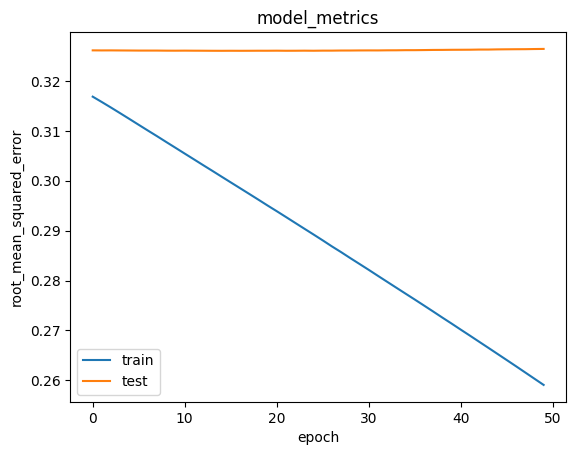

In [34]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model_metrics')
plt.ylabel('root_mean_squared_error')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

Dari visualisasi metrik pada output code cell di atas, dapat dilihat bahwa terjadi tren penurunan RMSE pada setiap epoch baik pada data training maupun data evaluasi. Hal ini mengindikasikan bahwa model dapat belajar dengan baik dari data. Dari visualisasi ini juga dapat dilihat bahwa diperoleh nilai error akhir sebesar 0.0.2623 dengan error pada data validasi sebesar 0.3264.

##### 6.2.5 Mengambil data sample rating

In [36]:
df_sample = pd.read_csv('/content/food-recommendation-system/ratings.csv')
sample_user = df_sample['User_ID'].sample(1).iloc[0]
user_ratings = df_sample[df_sample['User_ID'] == sample_user]

Mengambil makanan yang belum pernah dicoba oleh user

In [37]:
makanan_belum = df_makanan_baru[~df_makanan_baru['id'].isin(user_ratings['Food_ID'].values)]['id']
makanan_belum = list(set(makanan_belum).intersection(set(food2idx.keys())))
makanan_belum_idx = [[food2idx[x]] for x in makanan_belum]

user_encoded = user2idx[sample_user]
user_food_pairs = np.hstack((np.full((len(makanan_belum_idx), 1), user_encoded), makanan_belum_idx))
prediksi_rating = model_reco.predict(user_food_pairs).flatten()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


Mengambil 10 rekomendasi teratas

In [38]:
top_indices = prediksi_rating.argsort()[-10:][::-1]
rekomendasi_ids = [idx2food[makanan_belum_idx[i][0]] for i in top_indices]

print('Rekomendasi untuk User:', int(sample_user))
print('---' * 10)
print('Makanan yang pernah dinilai tinggi oleh user:')
top_user = user_ratings.sort_values(by='Rating', ascending=False).head(5)['Food_ID'].values
for row in df_makanan_baru[df_makanan_baru['id'].isin(top_user)].itertuples():
    print(row.food_name, ":", row.category)

print('---' * 10)
print('Top 10 rekomendasi makanan:')
for row in df_makanan_baru[df_makanan_baru['id'].isin(rekomendasi_ids)].itertuples():
    print(row.food_name, ":", row.category)

Rekomendasi untuk User: 6
------------------------------
Makanan yang pernah dinilai tinggi oleh user:
baked namak para : Snack
red wine braised mushroom flatbread : Italian
spiced almond banana jaggery cake : Dessert
berry parfait hazelnut white chocolate sable : Dessert
------------------------------
Top 10 rekomendasi makanan:
chocolate nero cookies : Dessert
spinach and feta crepes : French
sugar free modak : Japanese
crispy herb chicken : Italian
vegetable bruschetta : Italian
easy bread poha : Indian
egg paratha : Indian
eggless coffee cupcakes : Dessert
double chocolate easter cookies  : Dessert
black rice : Healthy_Food


Sel kode di atas melakukan rekomendasi makanan untuk pengguna dengan `User_ID` 6. Dari outputnya, dapat dilihat bahwa ada 10 makanan yang direkomendasikan untuk pengguna ini.